In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/natural-language-processing-with-disaster-tweets/sample_submission.csv
/kaggle/input/competitions/natural-language-processing-with-disaster-tweets/train.csv
/kaggle/input/competitions/natural-language-processing-with-disaster-tweets/test.csv


In [2]:
import os

project_path = "/kaggle/working/CrisisLens"

folders = [
    "data/fire_smoke",
    "data/incident_reports",
    "data/videos",
    "data/knowledge",
    "data/buildings",
    "data/scenarios",
    "src",
    "outputs"
]

for folder in folders:
    os.makedirs(os.path.join(project_path, folder), exist_ok=True)

print("CrisisLens project structure created successfully!")

CrisisLens project structure created successfully!


In [3]:
import random
import pandas as pd

In [4]:
hazards = [
    "fire",
    "smoke",
    "gas_leak",
    "electrical_hazard",
    "flood",
    "blocked_exit"
]

locations = [
    "Room 1",
    "Room 2",
    "Room 3",
    "Room 4",
    "Corridor A",
    "Corridor B",
    "Kitchen",
    "Server Room",
    "Laboratory",
    "Main Hall"
]

exits = [
    "Exit A",
    "Exit B",
    "Exit C"
]

severities = [
    "low",
    "medium",
    "high",
    "critical"
]

In [5]:
reports = []

for i in range(120):

    hazard = random.choice(hazards)
    location = random.choice(locations)
    severity = random.choice(severities)
    people = random.randint(1, 30)
    blocked_exit = random.choice(exits)
    
    hour = random.randint(8, 20)
    minute = random.randint(0, 59)
    time = f"{hour:02d}:{minute:02d}"

    text = (
        f"At {time}, {severity} {hazard} was reported near "
        f"{location}. There were {people} people in the area "
        f"and {blocked_exit} was blocked."
    )

    reports.append({
        "incident_id": i + 1,
        "text": text,
        "hazard": hazard,
        "location": location,
        "severity": severity,
        "people": people,
        "blocked_exit": blocked_exit,
        "time": time
    })

In [6]:
df = pd.DataFrame(reports)

df.head()

,incident_id,text,hazard,location,severity,people,blocked_exit,time
0,1,"At 14:13, high blocked_exit was reported near ...",blocked_exit,Room 4,high,3,Exit B,14:13
1,2,"At 20:05, high smoke was reported near Main Ha...",smoke,Main Hall,high,23,Exit A,20:05
2,3,"At 16:44, medium fire was reported near Room 4...",fire,Room 4,medium,27,Exit C,16:44
3,4,"At 08:40, critical gas_leak was reported near ...",gas_leak,Server Room,critical,2,Exit C,08:40
4,5,"At 14:33, low blocked_exit was reported near R...",blocked_exit,Room 3,low,7,Exit A,14:33


In [7]:
dataset_path = "/kaggle/working/CrisisLens/data/incident_reports/incident_reports.csv"

df.to_csv(dataset_path, index=False)

print(f"Dataset saved to: {dataset_path}")
print(f"Number of incidents: {len(df)}")

Dataset saved to: /kaggle/working/CrisisLens/data/incident_reports/incident_reports.csv
Number of incidents: 120


In [8]:
df.head(10)

,incident_id,text,hazard,location,severity,people,blocked_exit,time
0,1,"At 14:13, high blocked_exit was reported near ...",blocked_exit,Room 4,high,3,Exit B,14:13
1,2,"At 20:05, high smoke was reported near Main Ha...",smoke,Main Hall,high,23,Exit A,20:05
2,3,"At 16:44, medium fire was reported near Room 4...",fire,Room 4,medium,27,Exit C,16:44
3,4,"At 08:40, critical gas_leak was reported near ...",gas_leak,Server Room,critical,2,Exit C,08:40
4,5,"At 14:33, low blocked_exit was reported near R...",blocked_exit,Room 3,low,7,Exit A,14:33
5,6,"At 16:47, critical flood was reported near Roo...",flood,Room 3,critical,19,Exit C,16:47
6,7,"At 12:14, high fire was reported near Server R...",fire,Server Room,high,18,Exit A,12:14
7,8,"At 14:35, low electrical_hazard was reported n...",electrical_hazard,Server Room,low,12,Exit C,14:35
8,9,"At 18:50, low flood was reported near Main Hal...",flood,Main Hall,low,21,Exit C,18:50
9,10,"At 11:31, medium blocked_exit was reported nea...",blocked_exit,Server Room,medium,16,Exit A,11:31


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   incident_id   120 non-null    int64 
 1   text          120 non-null    object
 2   hazard        120 non-null    object
 3   location      120 non-null    object
 4   severity      120 non-null    object
 5   people        120 non-null    int64 
 6   blocked_exit  120 non-null    object
 7   time          120 non-null    object
dtypes: int64(2), object(6)
memory usage: 7.6+ KB


In [10]:
df["hazard"].value_counts()

hazard
blocked_exit         26
fire                 21
flood                21
gas_leak             20
smoke                17
electrical_hazard    15
Name: count, dtype: int64

In [11]:
!pip install -q langchain-classic

In [12]:
import random
import pandas as pd
import torch

from langchain_classic.output_parsers import (
    ResponseSchema,
    StructuredOutputParser
)

from langchain_classic.prompts import PromptTemplate

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig
)

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

In [22]:
from langchain_classic.output_parsers import (
    ResponseSchema,
    StructuredOutputParser
)

hazard_schema = ResponseSchema(
    name="hazard",
    description="The type of emergency hazard, such as fire, smoke, gas leak, flood, electrical hazard, or blocked exit."
)

location_schema = ResponseSchema(
    name="location",
    description="The exact location where the emergency incident occurred."
)

severity_schema = ResponseSchema(
    name="severity",
    description="The severity level of the incident: low, medium, high, or critical."
)

people_schema = ResponseSchema(
    name="people",
    description="The number of people present in the affected area."
)

blocked_exit_schema = ResponseSchema(
    name="blocked_exit",
    description="The exit that is blocked, if an exit is blocked."
)

time_schema = ResponseSchema(
    name="time",
    description="The time when the incident was reported."
)

response_schemas = [
    hazard_schema,
    location_schema,
    severity_schema,
    people_schema,
    blocked_exit_schema,
    time_schema
]

print("Response schemas created:", len(response_schemas))

Response schemas created: 6


In [23]:
parser = StructuredOutputParser.from_response_schemas(
    response_schemas
)

format_instructions = parser.get_format_instructions()

In [24]:
format_instructions = parser.get_format_instructions()

print(format_instructions)

The output should be a markdown code snippet formatted in the following schema, including the leading and trailing "```json" and "```":

```json
{
	"hazard": string  // The type of emergency hazard, such as fire, smoke, gas leak, flood, electrical hazard, or blocked exit.
	"location": string  // The exact location where the emergency incident occurred.
	"severity": string  // The severity level of the incident: low, medium, high, or critical.
	"people": string  // The number of people present in the affected area.
	"blocked_exit": string  // The exit that is blocked, if an exit is blocked.
	"time": string  // The time when the incident was reported.
}
```


In [26]:
from langchain_classic.prompts import PromptTemplate

In [27]:
prompt_template = PromptTemplate(
    template="""
You are an emergency incident information extraction system.

Analyze the following incident report and extract the required information.

Incident Report:
{incident_text}

{format_instructions}
""",
    input_variables=["incident_text"],
    partial_variables={
        "format_instructions": format_instructions
    }
)

print("Prompt template created successfully!")

Prompt template created successfully!


In [28]:
sample_incident = df.iloc[0]["text"]

formatted_prompt = prompt_template.format(
    incident_text=sample_incident
)

print(formatted_prompt)


You are an emergency incident information extraction system.

Analyze the following incident report and extract the required information.

Incident Report:
At 14:13, high blocked_exit was reported near Room 4. There were 3 people in the area and Exit B was blocked.

The output should be a markdown code snippet formatted in the following schema, including the leading and trailing "```json" and "```":

```json
{
	"hazard": string  // The type of emergency hazard, such as fire, smoke, gas leak, flood, electrical hazard, or blocked exit.
	"location": string  // The exact location where the emergency incident occurred.
	"severity": string  // The severity level of the incident: low, medium, high, or critical.
	"people": string  // The number of people present in the affected area.
	"blocked_exit": string  // The exit that is blocked, if an exit is blocked.
	"time": string  // The time when the incident was reported.
}
```



In [19]:
!pip install -q --force-reinstall "transformers==4.46.3" "tokenizers==0.20.3"

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.48.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
s3fs 2025.12.0 requires fsspec==2025.12.0, but you have fsspec 2026.9.0 which is incompatible.
litellm 1.85.7 requires tokenizers<1.0,>=0.21.0, but you have tokenizers 0.20.3 which is incompatible.
ydata-profiling 4.18.4 requires numpy<2.4,>=1.22, but you have numpy 2.5.3 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.20.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 2.3.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
gradio 6.26.0 requires huggingface-hub<2.0,>=1

In [20]:
import transformers
import tokenizers
import torch

print("Transformers:", transformers.__version__)
print("Tokenizers:", tokenizers.__version__)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Transformers: 4.46.3
Tokenizers: 0.20.3
PyTorch: 2.11.0+cu128
CUDA available: True


In [21]:
import pandas as pd

dataset_path = "/kaggle/working/CrisisLens/data/incident_reports/incident_reports.csv"

df = pd.read_csv(dataset_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst incident:")
print(df.iloc[0]["text"])

Dataset loaded successfully!
Shape: (120, 8)

Columns:
['incident_id', 'text', 'hazard', 'location', 'severity', 'people', 'blocked_exit', 'time']

First incident:
At 14:13, high blocked_exit was reported near Room 4. There were 3 people in the area and Exit B was blocked.


In [40]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch

model_name = "mistralai/Mistral-7B-Instruct-v0.2"

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

print("Model configuration created successfully!")

Model configuration created successfully!


In [32]:
from huggingface_hub import login

login()

In [35]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [41]:
from transformers import AutoModelForCausalLM

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=quantization_config,
    device_map="auto"
)

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/4.94G [00:00<?, ?B/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.54G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

In [42]:
inputs = tokenizer(
    formatted_prompt,
    return_tensors="pt"
)

inputs = {
    key: value.to(model.device)
    for key, value in inputs.items()
}

print("Prompt tokenized successfully!")
print("Input shape:", inputs["input_ids"].shape)

Prompt tokenized successfully!
Input shape: torch.Size([1, 253])


In [46]:
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=200,
        temperature=0.1,
        do_sample=True,
        pad_token_id=tokenizer.pad_token_id
    )

print("Generation completed!")

Generation completed!


In [49]:
generated_text = tokenizer.decode(
    outputs[0],
    skip_special_tokens=True
)

print(generated_text)


You are an emergency incident information extraction system.

Analyze the following incident report and extract the required information.

Incident Report:
At 14:13, high blocked_exit was reported near Room 4. There were 3 people in the area and Exit B was blocked.

The output should be a markdown code snippet formatted in the following schema, including the leading and trailing "```json" and "```":

```json
{
	"hazard": string  // The type of emergency hazard, such as fire, smoke, gas leak, flood, electrical hazard, or blocked exit.
	"location": string  // The exact location where the emergency incident occurred.
	"severity": string  // The severity level of the incident: low, medium, high, or critical.
	"people": string  // The number of people present in the affected area.
	"blocked_exit": string  // The exit that is blocked, if an exit is blocked.
	"time": string  // The time when the incident was reported.
}
```

```json
{
	"hazard": "blocked_exit",
	"location": "Room 4",
	"sever

In [50]:
response_text = generated_text[len(formatted_prompt):].strip()

print(response_text)

```json
{
	"hazard": "blocked_exit",
	"location": "Room 4",
	"severity": "medium",
	"people": "3",
	"blocked_exit": "Exit B",
	"time": "14:13"
}
```


In [51]:
parsed_response = parser.parse(response_text)

print("Response parsed successfully!")
print(parsed_response)

Response parsed successfully!
{'hazard': 'blocked_exit', 'location': 'Room 4', 'severity': 'medium', 'people': '3', 'blocked_exit': 'Exit B', 'time': '14:13'}


In [52]:
parsed_response["people"] = int(parsed_response["people"])

print(parsed_response)
print("People type:", type(parsed_response["people"]))

{'hazard': 'blocked_exit', 'location': 'Room 4', 'severity': 'medium', 'people': 3, 'blocked_exit': 'Exit B', 'time': '14:13'}
People type: <class 'int'>


In [54]:
def extract_incident(incident_text):
    # 1. Create the prompt
    formatted_prompt = prompt_template.format(
        incident_text=incident_text
    )

    # 2. Tokenize the prompt
    inputs = tokenizer(
        formatted_prompt,
        return_tensors="pt"
    )

    inputs = {
        key: value.to(model.device)
        for key, value in inputs.items()
    }

    # 3. Generate the response
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=200,
            temperature=0.1,
            do_sample=True,
            pad_token_id=tokenizer.pad_token_id
        )

    # 4. Decode the generated tokens
    generated_text = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    # 5. Remove the original prompt
    response_text = generated_text[
        len(formatted_prompt):
    ].strip()

    # 6. Parse the structured response
    parsed_response = parser.parse(response_text)

    # 7. Convert people to integer
    if parsed_response.get("people"):
        try:
            parsed_response["people"] = int(
                parsed_response["people"]
            )
        except ValueError:
            parsed_response["people"] = None

    return parsed_response

In [55]:
test_incident = df.iloc[1]["text"]

result = extract_incident(test_incident)

print("Incident:")
print(test_incident)

print("\nLLM Result:")
print(result)

Incident:
At 20:05, high smoke was reported near Main Hall. There were 23 people in the area and Exit A was blocked.

LLM Result:
{'hazard': 'smoke', 'location': 'Main Hall', 'severity': 'medium', 'people': 23, 'blocked_exit': 'Exit A', 'time': '20:05'}


In [58]:
import pandas as pd

rag_path = "/kaggle/input/datasets/abdelrahmannmohsenn/rag1forcrisis/train-00000-of-00001.parquet"

rag_df = pd.read_parquet(rag_path)

print("Dataset loaded successfully!")
print("Shape:", rag_df.shape)
print("\nColumns:")
print(rag_df.columns.tolist())

print("\nFirst 3 rows:")
display(rag_df.head(3))

Dataset loaded successfully!
Shape: (23298, 2)

Columns:
['conversations', 'source']

First 3 rows:


,conversations,source
0,"[{'from': 'human', 'value': 'What is the occup...",NFPA 101
1,"[{'from': 'human', 'value': 'What is the occup...",NFPA 101
2,"[{'from': 'human', 'value': 'What is the occup...",NFPA 101


In [62]:
def conversation_to_text(conversation):
    question = ""
    answer = ""

    for message in conversation:
        if message["from"] == "human":
            question = message["value"]

        elif message["from"] == "gpt":
            answer = message["value"]

    return f"Question:\n{question}\n\nAnswer:\n{answer}"


rag_df["text"] = rag_df["conversations"].apply(
    conversation_to_text
)

In [64]:
keywords = [
    "fire",
    "smoke",
    "evacuation",
    "evacuate",
    "exit",
    "emergency",
    "occupancy",
    "occupant",
    "egress",
    "blocked",
    "assembly"
]

pattern = "|".join(keywords)

relevant_rag_df = rag_df[
    rag_df["text"].str.contains(
        pattern,
        case=False,
        na=False
    )
].copy()

print("Original records:", len(rag_df))
print("Relevant records:", len(relevant_rag_df))
print(
    "Percentage kept:",
    round(len(relevant_rag_df) / len(rag_df) * 100, 2),
    "%"
)

Original records: 23298
Relevant records: 17685
Percentage kept: 75.91 %


In [68]:
from langchain_classic.schema import Document

documents = []

for _, row in relevant_rag_df.iterrows():
    documents.append(
        Document(
            page_content=row["text"],
            metadata={
                "source": row["source"]
            }
        )
    )

In [70]:
from langchain_classic.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50
)

chunks = text_splitter.split_documents(documents)

print("Original documents:", len(documents))
print("Total chunks:", len(chunks))


Original documents: 17685
Total chunks: 20936


In [72]:
!pip install -q langchain-community sentence-transformers

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 8.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 3.8 MB/s eta 0:00:00


In [73]:
from langchain_community.embeddings import HuggingFaceEmbeddings

print("HuggingFaceEmbeddings imported successfully.")

HuggingFaceEmbeddings imported successfully.


/tmp/ipykernel_441/2039955665.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.embeddings import HuggingFaceEmbeddings


In [74]:
embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

/tmp/ipykernel_441/2127729888.py:1: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [75]:
!pip install -q faiss-cpu

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 78.9 MB/s eta 0:00:00:00:010:01


In [76]:
from langchain_community.vectorstores import FAISS

vectorstore = FAISS.from_documents(
    chunks,
    embedding_model
)

print("FAISS vector store created successfully.")
print("Total vectors:", vectorstore.index.ntotal)

FAISS vector store created successfully.
Total vectors: 20936


In [77]:
query = "What should I do if an exit is blocked during an emergency?"

retrieved_docs = vectorstore.similarity_search(
    query,
    k=3
)

print("Retrieved documents:", len(retrieved_docs))

for i, doc in enumerate(retrieved_docs, start=1):
    print(f"\n--- Result {i} ---")
    print(doc.page_content)
    print("Source:", doc.metadata["source"])

Retrieved documents: 3

--- Result 1 ---
Question:
What should residents do if the primary escape route is blocked?

Answer:
Residents must be trained on actions to take if the primary escape route is blocked, as outlined in NFPA101, section 33.7.2.2. This training is essential for effective emergency response. (Source: NFPA101)
Source: NFPA101

--- Result 2 ---
Question:
How should exits be unlocked during an emergency?

Answer:
Exits must be unlocked automatically upon activation of the fire alarm system to facilitate quick evacuation. NFPA 72 specifies this requirement in section 21.10.3, ensuring that all occupants can exit safely without delay during an emergency. (Source: NFPA 72)
Source: NFPA 72

--- Result 3 ---
Question:
What is required for final exit doors in an emergency?

Answer:
Final exit doors must open into a place of ultimate safety, avoiding roadways unless adequate safety barriers are provided. They should be designed to minimize obstruction to the rapid dispersal o

In [78]:
retriever = vectorstore.as_retriever(
    search_kwargs={
        "k": 3
    }
)

In [80]:
context = "\n\n".join(
    doc.page_content
    for doc in retrieved_docs
)

print(context)

Question:
What should residents do if the primary escape route is blocked?

Answer:
Residents must be trained on actions to take if the primary escape route is blocked, as outlined in NFPA101, section 33.7.2.2. This training is essential for effective emergency response. (Source: NFPA101)

Question:
How should exits be unlocked during an emergency?

Answer:
Exits must be unlocked automatically upon activation of the fire alarm system to facilitate quick evacuation. NFPA 72 specifies this requirement in section 21.10.3, ensuring that all occupants can exit safely without delay during an emergency. (Source: NFPA 72)

Question:
What is required for final exit doors in an emergency?

Answer:
Final exit doors must open into a place of ultimate safety, avoiding roadways unless adequate safety barriers are provided. They should be designed to minimize obstruction to the rapid dispersal of persons from the building. (BS 9999, Section 10.4.4) (Source: BS 9999)


In [82]:
rag_prompt = f"""
You are an emergency safety assistant.

Answer the user's question using ONLY the provided safety information.

If the provided information is not sufficient to answer the question,
say that the available information is insufficient.

Safety Information:
{context}

User Question:
{query}

Provide a clear and concise answer.
"""

In [83]:
inputs = tokenizer(
    rag_prompt,
    return_tensors="pt"
)

inputs = {
    key: value.to(model.device)
    for key, value in inputs.items()
}

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=200,
        temperature=0.1,
        do_sample=True,
        pad_token_id=tokenizer.pad_token_id
    )

generated_text = tokenizer.decode(
    outputs[0],
    skip_special_tokens=True
)

response = generated_text[
    len(rag_prompt):
].strip()

print(response)

Answer:
The available information does not directly address the situation where an exit is blocked during an emergency. It is crucial for residents to be trained on alternative escape routes and emergency response procedures as outlined in NFPA101 and NFPA 72. (Sources: NFPA101, NFPA 72)


In [86]:
import networkx as nx

building_graph = nx.Graph()

In [91]:
building_graph.add_nodes_from([
    "Room 1",
    "Room 2",
    "Room 3",
    "Corridor A",
    "Corridor B",
    "Exit A",
    "Exit B"
])

In [92]:
building_graph.add_edge("Room 1", "Corridor A", distance=2)
building_graph.add_edge("Room 2", "Corridor A", distance=3)
building_graph.add_edge("Room 3", "Corridor B", distance=3)

building_graph.add_edge("Corridor A", "Exit A", distance=2)
building_graph.add_edge("Corridor A", "Corridor B", distance=2)
building_graph.add_edge("Corridor B", "Exit B", distance=2)

print("Edges in the building:")
for u, v, data in building_graph.edges(data=True):
    print(f"{u} -> {v} | Distance: {data['distance']}")

Edges in the building:
Room 1 -> Corridor A | Distance: 2
Room 2 -> Corridor A | Distance: 3
Room 3 -> Corridor B | Distance: 3
Corridor A -> Exit A | Distance: 2
Corridor A -> Corridor B | Distance: 2
Corridor B -> Exit B | Distance: 2


In [94]:
for u, v, data in building_graph.edges(data=True):
    data["risk"] = "low"
    data["blocked"] = False

In [95]:
building_graph["Corridor A"]["Exit A"]["risk"] = "high"
building_graph["Corridor A"]["Exit A"]["blocked"] = True

print("Emergency scenario applied.")
print(
    "Corridor A -> Exit A:",
    building_graph["Corridor A"]["Exit A"]
)

Emergency scenario applied.
Corridor A -> Exit A: {'distance': 2, 'risk': 'high', 'blocked': True}


In [110]:
RISK_PENALTIES = {
    "low": 0,
    "medium": 5,
    "high": 20,
    "critical": 100
}
for u, v, data in building_graph.edges(data=True):
    risk_penalty = RISK_PENALTIES[data["risk"]]
    data["cost"] = data["distance"] + risk_penalty

print("Edge costs:")
for u, v, data in building_graph.edges(data=True):
    print(
        f"{u} -> {v} | "
        f"distance={data['distance']} | "
        f"risk={data['risk']} | "
        f"cost={data['cost']}"
    )

Edge costs:
Room 1 -> Corridor A | distance=2 | risk=low | cost=2
Room 2 -> Corridor A | distance=3 | risk=low | cost=3
Room 3 -> Corridor B | distance=3 | risk=low | cost=3
Corridor A -> Exit A | distance=2 | risk=high | cost=22
Corridor A -> Corridor B | distance=2 | risk=low | cost=2
Corridor B -> Exit B | distance=2 | risk=low | cost=2


In [111]:
def find_safest_route(graph, start, exits):
    safe_graph = graph.copy()

    # Remove blocked edges
    blocked_edges = [
        (u, v)
        for u, v, data in safe_graph.edges(data=True)
        if data["blocked"]
    ]

    safe_graph.remove_edges_from(blocked_edges)

    best_route = None
    best_cost = float("inf")

    for exit_node in exits:

        try:
            route = nx.shortest_path(
                safe_graph,
                source=start,
                target=exit_node,
                weight="cost"
            )

            cost = nx.shortest_path_length(
                safe_graph,
                source=start,
                target=exit_node,
                weight="cost"
            )

            if cost < best_cost:
                best_cost = cost
                best_route = route

        except nx.NetworkXNoPath:
            continue

    return best_route, best_cost

In [112]:
route, distance = find_safe_route(
    building_graph,
    start="Room 1",
    exits=["Exit A", "Exit B"]
)

print("Recommended route:", route)
print("Total distance:", distance)

Recommended route: ['Room 1', 'Corridor A', 'Corridor B', 'Exit B']
Total distance: 6


In [113]:
route, cost = find_safest_route(
    building_graph,
    start="Room 1",
    exits=["Exit A", "Exit B"]
)

print("Safest route:", route)
print("Total route cost:", cost)

Safest route: ['Room 1', 'Corridor A', 'Corridor B', 'Exit B']
Total route cost: 6


In [114]:
# Open Exit A, but keep it high risk
building_graph["Corridor A"]["Exit A"]["blocked"] = False
building_graph["Corridor A"]["Exit A"]["risk"] = "high"

# Recalculate edge costs
for u, v, data in building_graph.edges(data=True):
    data["cost"] = (
        data["distance"]
        + RISK_PENALTIES[data["risk"]]
    )

route, cost = find_safest_route(
    building_graph,
    start="Room 1",
    exits=["Exit A", "Exit B"]
)

print("Safest route:", route)
print("Total route cost:", cost)

Safest route: ['Room 1', 'Corridor A', 'Corridor B', 'Exit B']
Total route cost: 6


In [115]:
def apply_incident_to_graph(graph, incident):
    location = incident.get("location")
    severity = incident.get("severity", "low")
    blocked_exit = incident.get("blocked_exit")

    # Apply hazard risk to edges connected to the incident location
    if location in graph.nodes:
        for neighbor in graph.neighbors(location):
            edge_data = graph[location][neighbor]

            edge_data["risk"] = severity

            edge_data["cost"] = (
                edge_data["distance"]
                + RISK_PENALTIES[severity]
            )

    # Block the reported exit
    if blocked_exit in graph.nodes:
        for neighbor in graph.neighbors(blocked_exit):
            graph[blocked_exit][neighbor]["blocked"] = True

    return graph

In [116]:
incident = {
    "hazard": "smoke",
    "location": "Exit A",
    "severity": "high",
    "people": 10,
    "blocked_exit": "Exit A",
    "time": "20:05"
}

apply_incident_to_graph(
    building_graph,
    incident
)

print("Incident applied successfully.")

print(
    "Exit A status:",
    building_graph["Corridor A"]["Exit A"]
)

Incident applied successfully.
Exit A status: {'distance': 2, 'risk': 'high', 'blocked': True, 'cost': 22}


In [117]:
route, cost = find_safest_route(
    building_graph,
    start="Room 1",
    exits=["Exit A", "Exit B"]
)

print("Incident:", incident)
print("\nRecommended safest route:")
print(" → ".join(route))
print("\nTotal route cost:", cost)

Incident: {'hazard': 'smoke', 'location': 'Exit A', 'severity': 'high', 'people': 10, 'blocked_exit': 'Exit A', 'time': '20:05'}

Recommended safest route:
Room 1 → Corridor A → Corridor B → Exit B

Total route cost: 6


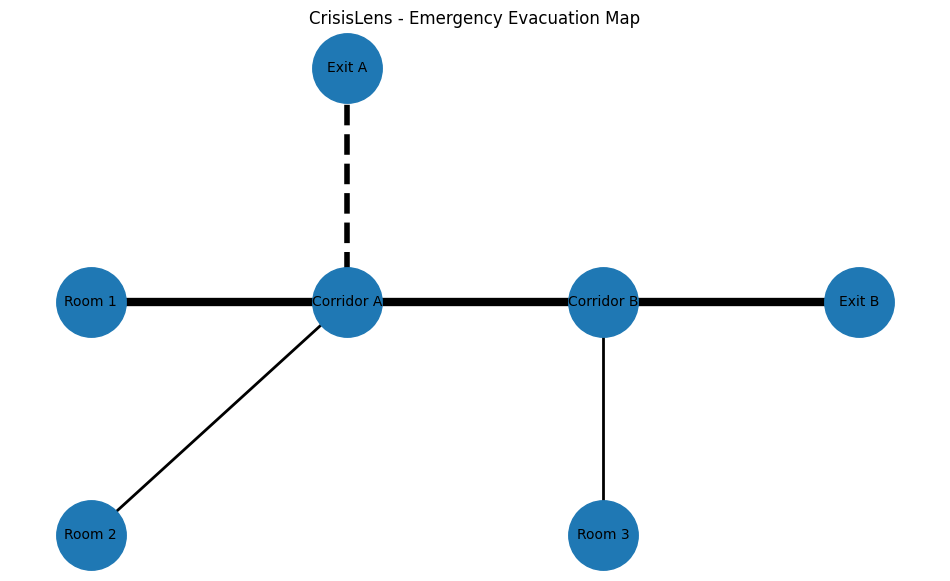

In [121]:
import matplotlib.pyplot as plt
import networkx as nx

# Positions of building nodes
positions = {
    "Room 1": (0, 2),
    "Room 2": (0, 0),
    "Room 3": (4, 0),
    "Corridor A": (2, 2),
    "Corridor B": (4, 2),
    "Exit A": (2, 4),
    "Exit B": (6, 2)
}

plt.figure(figsize=(12, 7))

# Separate normal and blocked edges
normal_edges = []
blocked_edges = []

for u, v, data in building_graph.edges(data=True):
    if data["blocked"]:
        blocked_edges.append((u, v))
    else:
        normal_edges.append((u, v))

# Draw normal edges
nx.draw_networkx_edges(
    building_graph,
    pos=positions,
    edgelist=normal_edges,
    width=2
)

# Draw blocked edges
nx.draw_networkx_edges(
    building_graph,
    pos=positions,
    edgelist=blocked_edges,
    width=4,
    style="dashed"
)

# Draw recommended route
route_edges = list(zip(route[:-1], route[1:]))

nx.draw_networkx_edges(
    building_graph,
    pos=positions,
    edgelist=route_edges,
    width=6
)

# Draw nodes
nx.draw_networkx_nodes(
    building_graph,
    pos=positions,
    node_size=2500
)

# Draw labels
nx.draw_networkx_labels(
    building_graph,
    pos=positions,
    font_size=10
)

plt.title("CrisisLens - Emergency Evacuation Map")
plt.axis("off")
plt.show()

In [122]:
def process_emergency(incident_text, start_location, exits):
    # 1. Extract structured incident information using Mistral
    incident = extract_incident(incident_text)

    # 2. Update the building graph based on the incident
    apply_incident_to_graph(
        building_graph,
        incident
    )

    # 3. Find the safest available route
    route, cost = find_safest_route(
        building_graph,
        start=start_location,
        exits=exits
    )

    # 4. Return the complete decision
    return {
        "incident": incident,
        "route": route,
        "route_cost": cost
    }

In [123]:
incident_text = """
At 20:05, high smoke was reported near Exit A.
There were 10 people in the area and Exit A was blocked.
"""

result = process_emergency(
    incident_text=incident_text,
    start_location="Room 1",
    exits=["Exit A", "Exit B"]
)

print("=== INCIDENT ===")
print(result["incident"])

print("\n=== RECOMMENDED ROUTE ===")
print(" → ".join(result["route"]))

print("\n=== ROUTE COST ===")
print(result["route_cost"])

=== INCIDENT ===
{'hazard': 'smoke', 'location': 'near Exit A', 'severity': 'medium', 'people': 10, 'blocked_exit': 'Exit A', 'time': '20:05'}

=== RECOMMENDED ROUTE ===
Room 1 → Corridor A → Corridor B → Exit B

=== ROUTE COST ===
6


In [127]:
from huggingface_hub import snapshot_download

fire_smoke_path = snapshot_download(
    repo_id="Dataclusterlabspvtltd/Fire-and-Smoke-Dataset",
    repo_type="dataset",
    local_dir="/kaggle/working/CrisisLens/data/fire_smoke"
)

print("Dataset downloaded successfully.")
print("Path:", fire_smoke_path)

Fetching 203 files:   0%|          | 0/203 [00:00<?, ?it/s]

(…)re%20and%20Smoke%20Sample%20%2814%29.xml:   0%|          | 0.00/740 [00:00<?, ?B/s]

(…)re%20and%20Smoke%20Sample%20%2813%29.xml:   0%|          | 0.00/741 [00:00<?, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

(…)e%20and%20Smoke%20Sample%20%28100%29.xml:   0%|          | 0.00/734 [00:00<?, ?B/s]

...

Datacluster Fire and Smoke Sample/Datacl(…):   0%|          | 0.00/31.1k [00:00<?, ?B/s]

Datacluster Fire and Smoke Sample/Datacl(…):   0%|          | 0.00/42.0k [00:00<?, ?B/s]

LICENSE: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

Dataset downloaded successfully.
Path: /kaggle/working/CrisisLens/data/fire_smoke


In [128]:
import os

fire_smoke_path = "/kaggle/working/CrisisLens/data/fire_smoke"

image_files = []

for root, dirs, files in os.walk(fire_smoke_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_files.append(os.path.join(root, file))

print("Total images:", len(image_files))

print("\nFirst 10 images:")
for image in image_files[:10]:
    print(image)

Total images: 100

First 10 images:
/kaggle/working/CrisisLens/data/fire_smoke/Datacluster Fire and Smoke Sample/Datacluster Fire and Smoke Sample (57).jpg
/kaggle/working/CrisisLens/data/fire_smoke/Datacluster Fire and Smoke Sample/Datacluster Fire and Smoke Sample (42).jpg
/kaggle/working/CrisisLens/data/fire_smoke/Datacluster Fire and Smoke Sample/Datacluster Fire and Smoke Sample (74).jpg
/kaggle/working/CrisisLens/data/fire_smoke/Datacluster Fire and Smoke Sample/Datacluster Fire and Smoke Sample (46).jpg
/kaggle/working/CrisisLens/data/fire_smoke/Datacluster Fire and Smoke Sample/Datacluster Fire and Smoke Sample (81).jpg
/kaggle/working/CrisisLens/data/fire_smoke/Datacluster Fire and Smoke Sample/Datacluster Fire and Smoke Sample (96).jpg
/kaggle/working/CrisisLens/data/fire_smoke/Datacluster Fire and Smoke Sample/Datacluster Fire and Smoke Sample (48).jpg
/kaggle/working/CrisisLens/data/fire_smoke/Datacluster Fire and Smoke Sample/Datacluster Fire and Smoke Sample (38).jpg
/kag

In [129]:
from transformers import BlipProcessor, BlipForConditionalGeneration

vision_model_name = "Salesforce/blip-image-captioning-base"

processor = BlipProcessor.from_pretrained(
    vision_model_name
)

vision_model = BlipForConditionalGeneration.from_pretrained(
    vision_model_name
)

vision_model = vision_model.to("cuda")

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

In [130]:
from PIL import Image
import torch

image_path = image_files[0]

image = Image.open(image_path).convert("RGB")

inputs = processor(
    images=image,
    return_tensors="pt"
)

inputs = {
    key: value.to("cuda")
    for key, value in inputs.items()
}

with torch.no_grad():
    output = vision_model.generate(
        **inputs,
        max_new_tokens=50
    )

caption = processor.decode(
    output[0],
    skip_special_tokens=True
)

print("Image:", image_path)
print("\nVision Description:")
print(caption)

Image: /kaggle/working/CrisisLens/data/fire_smoke/Datacluster Fire and Smoke Sample/Datacluster Fire and Smoke Sample (57).jpg

Vision Description:
a fire is lit in the dark


In [132]:
visual_incident_text = f"""
Visual observation from an emergency scene:

{caption}

Use this visual observation as evidence when analyzing the emergency.
"""

In [133]:
combined_incident = f"""
Visual observation:
{caption}

Incident report:
At 20:05, a fire was observed near Room 1.
There were 5 people in the area.
Exit A is available and Exit B is available.
"""

result = extract_incident(combined_incident)

print("=== EXTRACTED INCIDENT ===")
print(result)

=== EXTRACTED INCIDENT ===
{'hazard': 'fire', 'location': 'Room 1', 'severity': 'medium', 'people': 5, 'blocked_exit': 'N/A', 'time': '20:05'}


In [135]:
incident = result

safety_query = f"""
Emergency hazard: {incident['hazard']}
Location: {incident['location']}
Severity: {incident['severity']}
Blocked exit: {incident['blocked_exit']}

What safety procedures should be followed during this emergency,
especially regarding evacuation and blocked exits?
"""

retrieved_docs = retriever.invoke(safety_query)

safety_context = "\n\n".join(
    doc.page_content
    for doc in retrieved_docs
)

safety_sources = list({
    doc.metadata["source"]
    for doc in retrieved_docs
})

print("=== SAFETY CONTEXT ===")
print(safety_context)

print("\n=== SOURCES ===")
print(safety_sources)

=== SAFETY CONTEXT ===
Question:
What evacuation procedures are recommended for fire emergencies?

Question:
What should be considered for accessible exits in evacuation planning?

Question:
What should be included in the evacuation plan for accessible exits?

=== SOURCES ===
['NFPA Guidelines to Developing Emergency Action Plans for All Hazard Emergencies in High-Rise Office Buildings', 'NFPA Evacuation Guide for People with Disabilities', 'Emergency Evacuation Planning for People with Disabilities']


In [136]:
route, route_cost = find_safest_route(
    building_graph,
    start="Room 1",
    exits=["Exit A", "Exit B"]
)

final_decision = {
    "incident": incident,
    "safety_sources": safety_sources,
    "recommended_route": route,
    "route_cost": route_cost,
    "decision": "Evacuate using the recommended route and avoid blocked or high-risk paths."
}

print("=== CRISISLENS FINAL DECISION ===")

print("\nIncident:")
print(final_decision["incident"])

print("\nSafety Sources:")
for source in final_decision["safety_sources"]:
    print("-", source)

print("\nRecommended Route:")
print(" → ".join(final_decision["recommended_route"]))

print("\nRoute Cost:")
print(final_decision["route_cost"])

print("\nDecision:")
print(final_decision["decision"])

=== CRISISLENS FINAL DECISION ===

Incident:
{'hazard': 'fire', 'location': 'Room 1', 'severity': 'medium', 'people': 5, 'blocked_exit': 'N/A', 'time': '20:05'}

Safety Sources:
- NFPA Guidelines to Developing Emergency Action Plans for All Hazard Emergencies in High-Rise Office Buildings
- NFPA Evacuation Guide for People with Disabilities
- Emergency Evacuation Planning for People with Disabilities

Recommended Route:
Room 1 → Corridor A → Corridor B → Exit B

Route Cost:
6

Decision:
Evacuate using the recommended route and avoid blocked or high-risk paths.


In [140]:
def run_crisislens(
    incident_text,
    start_location,
    exits,
    visual_description=None
):
    # 1. Add visual information if an image was provided
    if visual_description:
        combined_text = f"""
Visual observation:
{visual_description}

Incident report:
{incident_text}
"""
    else:
        combined_text = incident_text

    # 2. Extract structured incident
    incident = extract_incident(combined_text)

    # 3. Retrieve safety information
    safety_query = f"""
    Emergency hazard: {incident['hazard']}
    Location: {incident['location']}
    Severity: {incident['severity']}
    Blocked exit: {incident['blocked_exit']}

    What safety procedures should be followed during this emergency?
    """

    retrieved_docs = retriever.invoke(safety_query)

    safety_context = "\n\n".join(
        doc.page_content
        for doc in retrieved_docs
    )

    safety_sources = list({
        doc.metadata["source"]
        for doc in retrieved_docs
    })

    # 4. Create a fresh copy of the building
    emergency_graph = building_graph.copy()

    # 5. Apply the incident only to this emergency
    apply_incident_to_graph(
        emergency_graph,
        incident
    )

    # 6. Calculate safest route
    route, route_cost = find_safest_route(
        emergency_graph,
        start=start_location,
        exits=exits
    )

    # 7. Return complete result
    return {
        "incident": incident,
        "safety_context": safety_context,
        "safety_sources": safety_sources,
        "recommended_route": route,
        "route_cost": route_cost
    }

In [141]:
incident_text = """
At 20:05, a fire was observed near Room 1.
There were 5 people in the area.
Exit A is available and Exit B is available.
"""

final_result = run_crisislens(
    incident_text=incident_text,
    start_location="Room 1",
    exits=["Exit A", "Exit B"],
    visual_description=caption
)

print("=== CRISISLENS RESULT ===")

print("\nIncident:")
print(final_result["incident"])

print("\nSafety Sources:")
for source in final_result["safety_sources"]:
    print("-", source)

print("\nRecommended Route:")
print(" → ".join(final_result["recommended_route"]))

print("\nRoute Cost:")
print(final_result["route_cost"])

=== CRISISLENS RESULT ===

Incident:
{'hazard': 'fire', 'location': 'Room 1', 'severity': 'medium', 'people': 5, 'blocked_exit': 'N/A', 'time': '20:05'}

Safety Sources:
- NFPA Guidelines to Developing Emergency Action Plans for All Hazard Emergencies in High-Rise Office Buildings
- NFPA Building Occupants Should They Stay or Should They Go
- SFPE Handbook of Fire Protection Engineering

Recommended Route:
Room 1 → Corridor A → Corridor B → Exit B

Route Cost:
11


In [142]:
!pip install -q streamlit pyngrok

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 31.8 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 97.9 MB/s eta 0:00:00:00:010:01


In [144]:
%%writefile /kaggle/working/CrisisLens/app.py

import streamlit as st

# =========================
# Page Configuration
# =========================

st.set_page_config(
    page_title="CrisisLens",
    page_icon="🚨",
    layout="wide"
)

# =========================
# Header
# =========================

st.title("🚨 CrisisLens")

st.subheader(
    "AI Emergency Response & Safe Evacuation System"
)

st.write(
    "Analyze emergency situations using multimodal AI, "
    "safety knowledge, risk assessment, and route optimization."
)

st.warning(
    "Prototype only — CrisisLens is a decision-support "
    "system and must not replace emergency authorities."
)

# =========================
# Input Section
# =========================

st.header("🚨 Emergency Information")

incident_text = st.text_area(
    "Incident Report",
    placeholder=(
        "Example: At 20:05, high smoke was reported "
        "near Room 1. There were 5 people in the area."
    ),
    height=150
)

uploaded_image = st.file_uploader(
    "Upload Emergency Image",
    type=["jpg", "jpeg", "png"]
)

col1, col2 = st.columns(2)

with col1:
    start_location = st.selectbox(
        "Starting Location",
        [
            "Room 1",
            "Room 2",
            "Room 3"
        ]
    )

with col2:
    exits = st.multiselect(
        "Available Exits",
        [
            "Exit A",
            "Exit B"
        ],
        default=[
            "Exit A",
            "Exit B"
        ]
    )

# =========================
# Analyze Button
# =========================

if st.button(
    "🚨 Analyze Emergency",
    type="primary",
    use_container_width=True
):

    if not incident_text:
        st.error("Please enter an incident report.")

    elif not exits:
        st.error("Please select at least one exit.")

    else:
        st.success("Emergency information received.")

        st.header("📋 Incident Analysis")

        st.write(incident_text)

        if uploaded_image:
            st.image(
                uploaded_image,
                caption="Uploaded Emergency Image",
                use_container_width=True
            )

        st.info(
            "AI analysis will be connected here next."
        )

Writing /kaggle/working/CrisisLens/app.py


In [145]:
!streamlit run /kaggle/working/CrisisLens/app.py \
    --server.port 8501 \
    --server.address 0.0.0.0

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)




2026-10-07 21:00:29.994 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.19.2.2:8501
  External URL: http://35.229.233.44:8501

^C
  Stopping...


In [147]:
import subprocess

process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "/kaggle/working/CrisisLens/app.py",
        "--server.port",
        "8501",
        "--server.address",
        "0.0.0.0"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

print("Streamlit started in background.")

Streamlit started in background.


In [149]:
from pyngrok import ngrok

ngrok.set_auth_token("3KNnyyO5HldgqaDCarkOe16YFLC_4ppVmkHyqtmNVHvJsR5Mm")

print("ngrok authentication configured.")

ngrok authentication configured.


In [150]:
public_url = ngrok.connect(8501)

print("CrisisLens URL:")
print(public_url)

CrisisLens URL:
NgrokTunnel: "https://unharmed-sniff-hatchback.ngrok-free.dev" -> "http://localhost:8501"


In [151]:
process.terminate()

print("Old Streamlit process stopped.")

Old Streamlit process stopped.


In [153]:
import subprocess

process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "/kaggle/working/CrisisLens/app.py",
        "--server.port",
        "8501",
        "--server.address",
        "0.0.0.0"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

print("CrisisLens Streamlit started.")


CrisisLens Streamlit started.


In [155]:
import time
time.sleep(10)

print("Checking Streamlit process...")
print("Process running:", process.poll() is None)

Checking Streamlit process...
Process running: True


In [156]:
%%writefile /kaggle/working/CrisisLens/app.py

import streamlit as st
import torch

from PIL import Image

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    BlipProcessor,
    BlipForConditionalGeneration
)

# =========================
# Page Configuration
# =========================

st.set_page_config(
    page_title="CrisisLens",
    page_icon="🚨",
    layout="wide"
)

# =========================
# Load Mistral
# =========================

@st.cache_resource
def load_mistral():

    model_name = "mistralai/Mistral-7B-Instruct-v0.2"

    tokenizer = AutoTokenizer.from_pretrained(
        model_name
    )

    quantization_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16
    )

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=quantization_config,
        device_map="auto"
    )

    tokenizer.pad_token = tokenizer.eos_token

    return tokenizer, model


# =========================
# Load BLIP
# =========================

@st.cache_resource
def load_vision_model():

    vision_model_name = "Salesforce/blip-image-captioning-base"

    processor = BlipProcessor.from_pretrained(
        vision_model_name
    )

    vision_model = BlipForConditionalGeneration.from_pretrained(
        vision_model_name
    )

    vision_model = vision_model.to("cuda")

    return processor, vision_model


tokenizer, model = load_mistral()

processor, vision_model = load_vision_model()

st.success("CrisisLens AI models loaded successfully.")

# =========================
# Header
# =========================

st.title("🚨 CrisisLens")

st.subheader(
    "AI Emergency Response & Safe Evacuation System"
)

st.write(
    "Analyze emergency situations using multimodal AI, "
    "safety knowledge, risk assessment, and route optimization."
)

st.warning(
    "Prototype only — CrisisLens is a decision-support "
    "system and must not replace emergency authorities."
)

# =========================
# Inputs
# =========================

st.header("🚨 Emergency Information")

incident_text = st.text_area(
    "Incident Report",
    placeholder=(
        "Example: At 20:05, smoke was reported near Room 1. "
        "There were 5 people in the area."
    ),
    height=150
)

uploaded_image = st.file_uploader(
    "Upload Emergency Image",
    type=["jpg", "jpeg", "png"]
)

col1, col2 = st.columns(2)

with col1:

    start_location = st.selectbox(
        "Starting Location",
        ["Room 1", "Room 2", "Room 3"]
    )

with col2:

    exits = st.multiselect(
        "Available Exits",
        ["Exit A", "Exit B"],
        default=["Exit A", "Exit B"]
    )

# =========================
# Analyze Image
# =========================

if uploaded_image:

    image = Image.open(uploaded_image).convert("RGB")

    st.image(
        image,
        caption="Uploaded Emergency Image",
        use_container_width=True
    )

    inputs = processor(
        images=image,
        return_tensors="pt"
    )

    inputs = {
        key: value.to("cuda")
        for key, value in inputs.items()
    }

    with torch.no_grad():

        output = vision_model.generate(
            **inputs,
            max_new_tokens=50
        )

    caption = processor.decode(
        output[0],
        skip_special_tokens=True
    )

    st.subheader("👁️ Visual Analysis")

    st.info(caption)

Overwriting /kaggle/working/CrisisLens/app.py


In [160]:
from pyngrok import ngrok

ngrok.kill()

public_url = ngrok.connect(
    addr="127.0.0.1:8501",
    proto="http"
)

print("CrisisLens URL:")
print(public_url)

CrisisLens URL:
NgrokTunnel: "https://unharmed-sniff-hatchback.ngrok-free.dev" -> "http://127.0.0.1:8501"


In [161]:
import socket

sock = socket.socket()
result = sock.connect_ex(("127.0.0.1", 8501))
sock.close()

if result == 0:
    print("Port 8501 is OPEN")
else:
    print("Port 8501 is NOT OPEN")

Port 8501 is NOT OPEN


In [162]:
process.terminate()

print("Old Streamlit process stopped.")

Old Streamlit process stopped.


In [163]:
import subprocess

log_file = open(
    "/kaggle/working/CrisisLens/streamlit.log",
    "w"
)

process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "/kaggle/working/CrisisLens/app.py",
        "--server.port",
        "8501",
        "--server.address",
        "127.0.0.1"
    ],
    stdout=log_file,
    stderr=subprocess.STDOUT
)

print("Streamlit process started.")

Streamlit process started.


In [164]:
import time

time.sleep(15)

log_file.flush()

with open(
    "/kaggle/working/CrisisLens/streamlit.log",
    "r"
) as f:
    print(f.read())
    



2026-10-07 21:22:20.052 Uvicorn server started on 127.0.0.1:8501

  You can now view your Streamlit app in your browser.

  URL: http://127.0.0.1:8501




In [165]:
import socket

sock = socket.socket()
result = sock.connect_ex(("127.0.0.1", 8501))
sock.close()

if result == 0:
    print("✅ Port 8501 is OPEN")
else:
    print("❌ Port 8501 is NOT OPEN")

✅ Port 8501 is OPEN


In [166]:
!pip install -q pyngrok

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [167]:
from pyngrok import ngrok

ngrok.kill()

public_url = ngrok.connect(
    "127.0.0.1:8501",
    proto="http"
)

print(public_url)

NgrokTunnel: "https://unharmed-sniff-hatchback.ngrok-free.dev" -> "http://127.0.0.1:8501"


In [170]:
from IPython.display import FileLink

image_path = "/kaggle/working/CrisisLens/data/fire_smoke/Datacluster Fire and Smoke Sample/Datacluster Fire and Smoke Sample (57).jpg"

FileLink(image_path)

/kaggle/working/CrisisLens/data/fire_smoke/Datacluster Fire and Smoke Sample/Datacluster Fire and Smoke Sample (57).jpg

In [173]:
vectorstore.save_local(
    "/kaggle/working/CrisisLens/vectorstore"
)

print("✅ FAISS vectorstore saved successfully.")

✅ FAISS vectorstore saved successfully.


In [174]:
import os

vectorstore_path = "/kaggle/working/CrisisLens/vectorstore"

print("Files saved:")
for file in os.listdir(vectorstore_path):
    print(" -", file)

Files saved:
 - index.pkl
 - index.faiss


In [176]:
%%writefile /kaggle/working/CrisisLens/app.py

import streamlit as st
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

st.set_page_config(
    page_title="CrisisLens",
    page_icon="🚨",
    layout="wide"
)

st.title("🚨 CrisisLens")

@st.cache_resource
def load_rag():
    embedding_model = HuggingFaceEmbeddings(
        model_name="sentence-transformers/all-MiniLM-L6-v2"
    )

    vectorstore = FAISS.load_local(
        "/kaggle/working/CrisisLens/vectorstore",
        embedding_model,
        allow_dangerous_deserialization=True
    )

    retriever = vectorstore.as_retriever(
        search_kwargs={"k": 3}
    )

    return retriever


retriever = load_rag()

st.success("✅ RAG system loaded successfully!")

query = st.text_input(
    "Test safety question",
    "What should I do if an exit is blocked during an emergency?"
)

if st.button("Test RAG"):
    docs = retriever.invoke(query)

    st.subheader("📚 Retrieved Safety Information")

    for i, doc in enumerate(docs, 1):
        st.markdown(f"### Source {i}")
        st.write(doc.page_content)
        st.caption(doc.metadata.get("source", "Unknown source"))

Overwriting /kaggle/working/CrisisLens/app.py


In [177]:
process.terminate()
process.wait()

print("✅ Old Streamlit process stopped.")

✅ Old Streamlit process stopped.


In [178]:
import subprocess

log_file = open(
    "/kaggle/working/CrisisLens/streamlit.log",
    "w"
)

process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "/kaggle/working/CrisisLens/app.py",
        "--server.port",
        "8501",
        "--server.address",
        "127.0.0.1"
    ],
    stdout=log_file,
    stderr=subprocess.STDOUT
)

print("🚀 New Streamlit process started.")

🚀 New Streamlit process started.


In [179]:
import time
time.sleep(15)

with open("/kaggle/working/CrisisLens/streamlit.log", "r") as f:
    print(f.read())



2026-10-07 21:44:52.136 Uvicorn server started on 127.0.0.1:8501

  You can now view your Streamlit app in your browser.

  URL: http://127.0.0.1:8501




In [180]:
%%writefile /kaggle/working/CrisisLens/app.py

import streamlit as st
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig
)

from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

from langchain_classic.output_parsers import (
    ResponseSchema,
    StructuredOutputParser
)

from langchain_classic.prompts import PromptTemplate


# ============================================================
# PAGE CONFIG
# ============================================================

st.set_page_config(
    page_title="CrisisLens",
    page_icon="🚨",
    layout="wide"
)


# ============================================================
# TITLE
# ============================================================

st.title("🚨 CrisisLens")
st.subheader("AI Emergency Response & Safe Evacuation System")

st.warning(
    "Prototype only — CrisisLens is a decision-support system "
    "and must not replace emergency authorities."
)


# ============================================================
# LOAD MISTRAL
# ============================================================

@st.cache_resource
def load_mistral():

    model_name = "mistralai/Mistral-7B-Instruct-v0.2"

    tokenizer = AutoTokenizer.from_pretrained(
        model_name
    )

    quantization_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16
    )

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=quantization_config,
        device_map="auto"
    )

    tokenizer.pad_token = tokenizer.eos_token

    return tokenizer, model


# ============================================================
# LOAD RAG
# ============================================================

@st.cache_resource
def load_rag():

    embedding_model = HuggingFaceEmbeddings(
        model_name="sentence-transformers/all-MiniLM-L6-v2"
    )

    vectorstore = FAISS.load_local(
        "/kaggle/working/CrisisLens/vectorstore",
        embedding_model,
        allow_dangerous_deserialization=True
    )

    retriever = vectorstore.as_retriever(
        search_kwargs={"k": 3}
    )

    return retriever


# ============================================================
# STRUCTURED OUTPUT PARSER
# ============================================================

response_schemas = [

    ResponseSchema(
        name="hazard",
        description="Type of emergency hazard"
    ),

    ResponseSchema(
        name="location",
        description="Location where the emergency occurred"
    ),

    ResponseSchema(
        name="severity",
        description="Severity level: low, medium, high, or critical"
    ),

    ResponseSchema(
        name="people",
        description="Number of people affected"
    ),

    ResponseSchema(
        name="blocked_exit",
        description="Blocked exit if mentioned, otherwise N/A"
    ),

    ResponseSchema(
        name="time",
        description="Time of incident if mentioned, otherwise N/A"
    )
]


parser = StructuredOutputParser.from_response_schemas(
    response_schemas
)

format_instructions = parser.get_format_instructions()


# ============================================================
# LOAD MODELS
# ============================================================

with st.spinner("Loading CrisisLens AI models..."):

    tokenizer, model = load_mistral()
    retriever = load_rag()


st.success("✅ Mistral + RAG loaded successfully!")


# ============================================================
# INCIDENT INPUT
# ============================================================

st.header("🚨 Emergency Information")

incident_text = st.text_area(
    "Incident Report",
    height=150,
    placeholder=(
        "Example: At 20:05, a fire was observed near Room 1. "
        "There were 5 people in the area. "
        "Exit A and Exit B are available."
    )
)


# ============================================================
# INCIDENT ANALYSIS
# ============================================================

if st.button(
    "🔍 Analyze Incident",
    type="primary",
    use_container_width=True
):

    if not incident_text.strip():

        st.error("Please enter an incident report.")

    else:

        prompt = f"""
You are an emergency incident information extraction system.

Analyze the following incident report.

Incident Report:
{incident_text}

Extract the following information:

- hazard
- location
- severity
- people
- blocked_exit
- time

{format_instructions}

Return ONLY the structured output.
"""

        # ----------------------------------------------------
        # TOKENIZATION
        # ----------------------------------------------------

        inputs = tokenizer(
            prompt,
            return_tensors="pt"
        )

        inputs = {
            key: value.to(model.device)
            for key, value in inputs.items()
        }


        # ----------------------------------------------------
        # MISTRAL INFERENCE
        # ----------------------------------------------------

        with torch.no_grad():

            output = model.generate(
                **inputs,
                max_new_tokens=200,
                temperature=0.1,
                do_sample=True,
                pad_token_id=tokenizer.pad_token_id
            )


        # ----------------------------------------------------
        # DECODE
        # ----------------------------------------------------

        generated_text = tokenizer.decode(
            output[0],
            skip_special_tokens=True
        )


        # Remove original prompt
        generated_text = generated_text[len(prompt):].strip()


        # ----------------------------------------------------
        # PARSE JSON
        # ----------------------------------------------------

        try:

            incident = parser.parse(
                generated_text
            )

            st.subheader("📋 Incident Analysis")

            st.json(incident)

        except Exception as e:

            st.error(
                "Could not parse the model output."
            )

            st.write("Raw model output:")

            st.code(
                generated_text
            )

            st.write("Parser error:")

            st.write(e)

Overwriting /kaggle/working/CrisisLens/app.py


In [181]:
process.terminate()
process.wait()

print("✅ Old Streamlit process stopped.")

✅ Old Streamlit process stopped.


In [182]:
import subprocess

log_file = open(
    "/kaggle/working/CrisisLens/streamlit.log",
    "w"
)

process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "/kaggle/working/CrisisLens/app.py",
        "--server.port",
        "8501",
        "--server.address",
        "127.0.0.1"
    ],
    stdout=log_file,
    stderr=subprocess.STDOUT
)

print("🚀 Streamlit started.")

🚀 Streamlit started.


In [183]:
import time
time.sleep(20)

with open("/kaggle/working/CrisisLens/streamlit.log", "r") as f:
    print(f.read())



2026-10-07 21:47:58.041 Uvicorn server started on 127.0.0.1:8501

  You can now view your Streamlit app in your browser.

  URL: http://127.0.0.1:8501




In [184]:
%%writefile /kaggle/working/CrisisLens/app.py

import streamlit as st
import torch
import networkx as nx
import matplotlib.pyplot as plt

from PIL import Image

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    BlipProcessor,
    BlipForConditionalGeneration
)

from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

from langchain_classic.output_parsers import (
    ResponseSchema,
    StructuredOutputParser
)


# ============================================================
# PAGE CONFIG
# ============================================================

st.set_page_config(
    page_title="CrisisLens",
    page_icon="🚨",
    layout="wide"
)


# ============================================================
# TITLE
# ============================================================

st.title("🚨 CrisisLens")
st.subheader(
    "AI Emergency Response & Safe Evacuation System"
)

st.warning(
    "Prototype only — CrisisLens is a decision-support system "
    "and must not replace emergency authorities."
)


# ============================================================
# LOAD MISTRAL
# ============================================================

@st.cache_resource
def load_mistral():

    model_name = "mistralai/Mistral-7B-Instruct-v0.2"

    tokenizer = AutoTokenizer.from_pretrained(
        model_name
    )

    quantization_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16
    )

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=quantization_config,
        device_map="auto"
    )

    tokenizer.pad_token = tokenizer.eos_token

    return tokenizer, model


# ============================================================
# LOAD BLIP
# ============================================================

@st.cache_resource
def load_vision_model():

    model_name = "Salesforce/blip-image-captioning-base"

    processor = BlipProcessor.from_pretrained(
        model_name
    )

    vision_model = BlipForConditionalGeneration.from_pretrained(
        model_name
    )

    vision_model = vision_model.to("cuda")

    return processor, vision_model


# ============================================================
# LOAD RAG
# ============================================================

@st.cache_resource
def load_rag():

    embedding_model = HuggingFaceEmbeddings(
        model_name="sentence-transformers/all-MiniLM-L6-v2"
    )

    vectorstore = FAISS.load_local(
        "/kaggle/working/CrisisLens/vectorstore",
        embedding_model,
        allow_dangerous_deserialization=True
    )

    retriever = vectorstore.as_retriever(
        search_kwargs={"k": 3}
    )

    return retriever


# ============================================================
# STRUCTURED OUTPUT
# ============================================================

response_schemas = [

    ResponseSchema(
        name="hazard",
        description="Type of emergency hazard"
    ),

    ResponseSchema(
        name="location",
        description="Location where the emergency occurred"
    ),

    ResponseSchema(
        name="severity",
        description="Severity: low, medium, high, or critical"
    ),

    ResponseSchema(
        name="people",
        description="Number of people affected"
    ),

    ResponseSchema(
        name="blocked_exit",
        description="Blocked exit if mentioned, otherwise N/A"
    ),

    ResponseSchema(
        name="time",
        description="Time of incident if mentioned, otherwise N/A"
    )
]

parser = StructuredOutputParser.from_response_schemas(
    response_schemas
)

format_instructions = parser.get_format_instructions()


# ============================================================
# BUILDING GRAPH
# ============================================================

def create_building_graph():

    graph = nx.Graph()

    graph.add_nodes_from([
        "Room 1",
        "Room 2",
        "Room 3",
        "Corridor A",
        "Corridor B",
        "Exit A",
        "Exit B"
    ])

    graph.add_edge(
        "Room 1",
        "Corridor A",
        distance=2
    )

    graph.add_edge(
        "Room 2",
        "Corridor A",
        distance=3
    )

    graph.add_edge(
        "Room 3",
        "Corridor B",
        distance=3
    )

    graph.add_edge(
        "Corridor A",
        "Exit A",
        distance=2
    )

    graph.add_edge(
        "Corridor A",
        "Corridor B",
        distance=2
    )

    graph.add_edge(
        "Corridor B",
        "Exit B",
        distance=2
    )

    for u, v, data in graph.edges(data=True):

        data["risk"] = "low"
        data["blocked"] = False
        data["cost"] = data["distance"]

    return graph


# ============================================================
# RISK PENALTIES
# ============================================================

RISK_PENALTIES = {
    "low": 0,
    "medium": 5,
    "high": 20,
    "critical": 100
}


# ============================================================
# APPLY INCIDENT TO GRAPH
# ============================================================

def apply_incident_to_graph(
    graph,
    incident
):

    location = incident.get(
        "location",
        ""
    )

    severity = incident.get(
        "severity",
        "low"
    ).lower()

    blocked_exit = incident.get(
        "blocked_exit",
        "N/A"
    )

    if severity not in RISK_PENALTIES:
        severity = "low"


    # Apply hazard risk around incident location

    if location in graph.nodes:

        for neighbor in graph.neighbors(location):

            edge = graph[location][neighbor]

            edge["risk"] = severity

            edge["cost"] = (
                edge["distance"]
                + RISK_PENALTIES[severity]
            )


    # Block exit

    if blocked_exit in graph.nodes:

        for neighbor in graph.neighbors(
            blocked_exit
        ):

            graph[blocked_exit][neighbor][
                "blocked"
            ] = True

    return graph


# ============================================================
# FIND SAFEST ROUTE
# ============================================================

def find_safest_route(
    graph,
    start,
    exits
):

    safe_graph = graph.copy()

    blocked_edges = []

    for u, v, data in safe_graph.edges(
        data=True
    ):

        if data["blocked"]:

            blocked_edges.append(
                (u, v)
            )

    safe_graph.remove_edges_from(
        blocked_edges
    )


    best_route = None
    best_cost = float("inf")


    for exit_node in exits:

        try:

            route = nx.shortest_path(
                safe_graph,
                source=start,
                target=exit_node,
                weight="cost"
            )

            cost = nx.shortest_path_length(
                safe_graph,
                source=start,
                target=exit_node,
                weight="cost"
            )

            if cost < best_cost:

                best_cost = cost
                best_route = route

        except nx.NetworkXNoPath:

            continue


    return best_route, best_cost


# ============================================================
# DRAW BUILDING MAP
# ============================================================

def draw_building_map(
    graph,
    route=None
):

    positions = {
        "Room 1": (-2, 1),
        "Room 2": (-2, -1),
        "Room 3": (0, -2),
        "Corridor A": (0, 0),
        "Corridor B": (2, 0),
        "Exit A": (2, 1),
        "Exit B": (4, 0)
    }

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )

    # Normal edges

    for u, v, data in graph.edges(
        data=True
    ):

        x1, y1 = positions[u]
        x2, y2 = positions[v]

        if data["blocked"]:

            ax.plot(
                [x1, x2],
                [y1, y2],
                linestyle="--",
                linewidth=3
            )

        else:

            ax.plot(
                [x1, x2],
                [y1, y2],
                linewidth=2
            )


    # Recommended route

    if route:

        for i in range(
            len(route) - 1
        ):

            u = route[i]
            v = route[i + 1]

            x1, y1 = positions[u]
            x2, y2 = positions[v]

            ax.plot(
                [x1, x2],
                [y1, y2],
                linewidth=6
            )


    # Nodes

    for node, (x, y) in positions.items():

        ax.scatter(
            x,
            y,
            s=1000
        )

        ax.text(
            x,
            y,
            node,
            ha="center",
            va="center",
            fontsize=9
        )


    ax.set_title(
        "CrisisLens Building Evacuation Map"
    )

    ax.axis("off")

    return fig


# ============================================================
# LOAD ALL MODELS
# ============================================================

with st.spinner(
    "Loading CrisisLens AI models..."
):

    tokenizer, model = load_mistral()

    processor, vision_model = load_vision_model()

    retriever = load_rag()


st.success(
    "✅ CrisisLens AI system loaded successfully!"
)


# ============================================================
# INPUT SECTION
# ============================================================

st.header("🚨 Emergency Information")


incident_text = st.text_area(
    "Incident Report",
    height=150,
    placeholder=(
        "Example:\n"
        "At 20:05, a fire was observed near Room 1.\n"
        "There were 5 people in the area.\n"
        "Exit A and Exit B are available."
    )
)


uploaded_image = st.file_uploader(
    "Upload Emergency Image",
    type=[
        "jpg",
        "jpeg",
        "png"
    ]
)


col1, col2 = st.columns(2)


with col1:

    start_location = st.selectbox(
        "Evacuation Starting Location",
        [
            "Room 1",
            "Room 2",
            "Room 3"
        ]
    )


with col2:

    exits = st.multiselect(
        "Available Exits",
        [
            "Exit A",
            "Exit B"
        ],
        default=[
            "Exit A",
            "Exit B"
        ]
    )


# ============================================================
# VISUAL ANALYSIS
# ============================================================

visual_description = ""


if uploaded_image:

    image = Image.open(
        uploaded_image
    ).convert("RGB")

    st.image(
        image,
        caption="Uploaded Emergency Image",
        use_container_width=True
    )


    with st.spinner(
        "Analyzing image..."
    ):

        inputs = processor(
            images=image,
            return_tensors="pt"
        )

        inputs = {
            key: value.to("cuda")
            for key, value in inputs.items()
        }


        with torch.no_grad():

            output = vision_model.generate(
                **inputs,
                max_new_tokens=50
            )


        visual_description = processor.decode(
            output[0],
            skip_special_tokens=True
        )


    st.subheader(
        "👁️ Visual Analysis"
    )

    st.info(
        visual_description
    )


# ============================================================
# MAIN ANALYSIS
# ============================================================

if st.button(
    "🚨 Analyze Emergency",
    type="primary",
    use_container_width=True
):

    if not incident_text.strip():

        st.error(
            "Please enter an incident report."
        )

        st.stop()


    if not exits:

        st.error(
            "Please select at least one available exit."
        )

        st.stop()


    # ========================================================
    # COMBINE TEXT + VISION
    # ========================================================

    if visual_description:

        combined_text = f"""
Visual Observation:
{visual_description}

Incident Report:
{incident_text}
"""

    else:

        combined_text = incident_text


    # ========================================================
    # MISTRAL INCIDENT EXTRACTION
    # ========================================================

    with st.spinner(
        "Understanding emergency situation..."
    ):

        prompt = f"""
You are an emergency incident information extraction system.

Analyze the following emergency information.

{combined_text}

Extract:

- hazard
- location
- severity
- people
- blocked_exit
- time

{format_instructions}

Return ONLY the structured output.
"""


        inputs = tokenizer(
            prompt,
            return_tensors="pt"
        )

        inputs = {
            key: value.to(model.device)
            for key, value in inputs.items()
        }


        with torch.no_grad():

            output = model.generate(
                **inputs,
                max_new_tokens=200,
                temperature=0.1,
                do_sample=True,
                pad_token_id=tokenizer.pad_token_id
            )


        generated_text = tokenizer.decode(
            output[0],
            skip_special_tokens=True
        )


        generated_text = generated_text[
            len(prompt):
        ].strip()


        try:

            incident = parser.parse(
                generated_text
            )

        except Exception:

            st.error(
                "Could not parse the emergency information."
            )

            st.code(
                generated_text
            )

            st.stop()


    # ========================================================
    # INCIDENT RESULT
    # ========================================================

    st.header(
        "📋 Incident Analysis"
    )

    st.json(
        incident
    )


    # ========================================================
    # RAG
    # ========================================================

    with st.spinner(
        "Retrieving emergency safety procedures..."
    ):

        safety_query = f"""
Emergency hazard: {incident.get("hazard")}
Location: {incident.get("location")}
Severity: {incident.get("severity")}
Blocked exit: {incident.get("blocked_exit")}

What safety procedures should be followed during this emergency?
"""

        retrieved_docs = retriever.invoke(
            safety_query
        )


    st.header(
        "📚 Safety Knowledge"
    )


    for i, doc in enumerate(
        retrieved_docs,
        1
    ):

        with st.expander(
            f"Safety Source {i}"
        ):

            st.write(
                doc.page_content
            )

            st.caption(
                doc.metadata.get(
                    "source",
                    "Unknown source"
                )
            )


    # ========================================================
    # ROUTE OPTIMIZATION
    # ========================================================

    st.header(
        "🧭 Safe Evacuation Route"
    )


    graph = create_building_graph()


    graph = apply_incident_to_graph(
        graph,
        incident
    )


    route, route_cost = find_safest_route(
        graph,
        start=start_location,
        exits=exits
    )


    if route is None:

        st.error(
            "🚨 No safe feasible evacuation route was found."
        )

    else:

        st.success(
            "✅ Safest feasible route identified."
        )


        st.subheader(
            "Recommended Route"
        )

        st.write(
            " → ".join(route)
        )


        st.metric(
            "Route Cost",
            route_cost
        )


        # ====================================================
        # MAP
        # ====================================================

        fig = draw_building_map(
            graph,
            route
        )

        st.pyplot(
            fig,
            use_container_width=True
        )


    # ========================================================
    # FINAL DECISION
    # ========================================================

    st.header(
        "🚨 CrisisLens Decision"
    )


    if route:

        st.success(
            f"""
Recommended evacuation route:

{" → ".join(route)}

Route cost: {route_cost}

The route was selected using distance and
hazard-risk penalties.
"""
        )

    else:

        st.error(
            "No feasible evacuation route is currently available."
        )

Overwriting /kaggle/working/CrisisLens/app.py


In [185]:
process.terminate()
process.wait()

print("✅ Old Streamlit stopped.")

✅ Old Streamlit stopped.


In [186]:
import subprocess

log_file = open(
    "/kaggle/working/CrisisLens/streamlit.log",
    "w"
)

process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "/kaggle/working/CrisisLens/app.py",
        "--server.port",
        "8501",
        "--server.address",
        "127.0.0.1"
    ],
    stdout=log_file,
    stderr=subprocess.STDOUT
)

print("🚀 CrisisLens started.")

🚀 CrisisLens started.


https://unharmed-sniff-hatchback.ngrok-free.dev?utm_source=chatgpt.com